In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [4]:
#read the data

# Read the CSV
df = pd.read_csv('../data/gas_price_2526.csv')

# Parse date column and set index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

# Keep only the target column
df = df[["daily price"]]

print(df.head())
print(df.index.min(), "→", df.index.max())


            daily price
date                   
2025-01-19        39.85
2025-01-20        37.21
2025-01-21        37.33
2025-01-22        37.85
2025-01-23        35.70
2025-01-19 00:00:00 → 2026-06-02 00:00:00


C:\Users\sagal\AppData\Local\Temp\ipykernel_47784\2674796368.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [5]:
#train test split

train, test = train_test_split(
    df["daily price"],
    test_size=0.20,
    shuffle=False  # time series → no shuffle
)


In [6]:
#scale data

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))


In [7]:
#30 day lookback
lookback = 30

def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


In [8]:
#training sequences

X_train, y_train = create_sequences(train_scaled, lookback)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
y_train = y_train.reshape(-1, 1)


In [9]:
combined_scaled = np.concatenate([
    train_scaled[-lookback:],   
    test_scaled                 
], axis=0)

X_test, y_test = create_sequences(combined_scaled, lookback)

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
y_test = y_test.reshape(-1, 1)


In [10]:
#lstm model
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(lookback, 1)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#train lstm
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0706 - val_loss: 0.0066
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0246 - val_loss: 0.0057
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0346 - val_loss: 0.0122
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0093 - val_loss: 0.0033
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0105 - val_loss: 8.6628e-04
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0092 - val_loss: 0.0015
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0082 - val_loss: 9.3840e-04
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0072 - val_loss: 9.8537e-04
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0065 - val_loss: 9.2751e-04
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0066 - val_loss: 0.0010
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0067 - val_loss: 9.2586e-04
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [12]:
#predict on test data

y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)

y_test_actual = scaler.inverse_transform(y_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [13]:
#evaluate the model

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)


RMSE: 2.4445989461546107
MAE : 1.9292556396484377


In [14]:
#cI
residuals = y_test_actual.flatten() - y_pred.flatten()
residual_std = np.std(residuals)

lower_ci = y_pred.flatten() - 1.96 * residual_std
upper_ci = y_pred.flatten() + 1.96 * residual_std


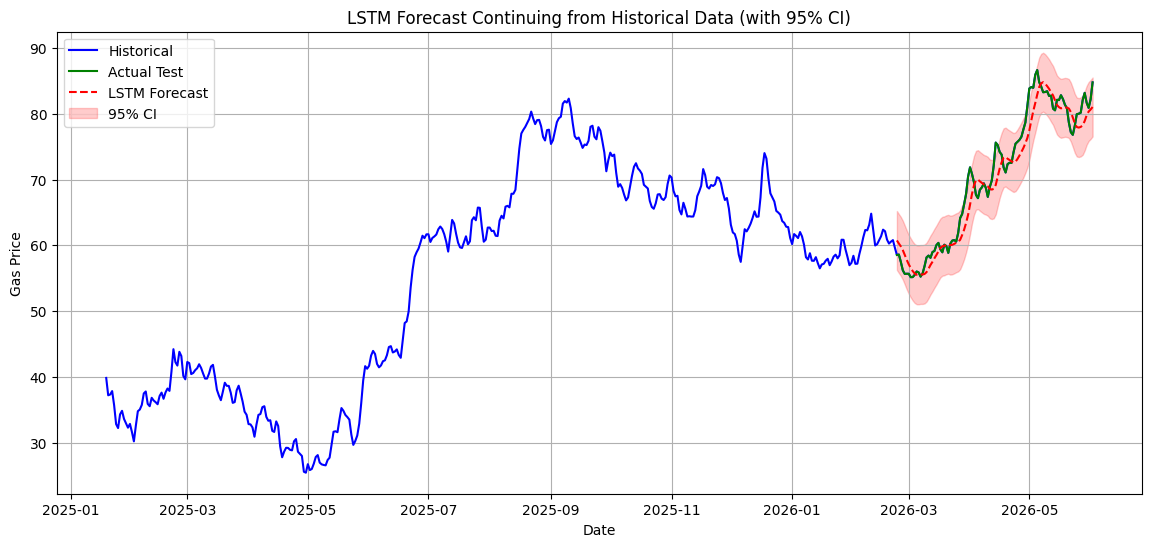

In [15]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df["daily price"], label="Historical", color="blue")
plt.plot(test.index, y_test_actual, label="Actual Test", color="green")
plt.plot(test.index, y_pred, label="LSTM Forecast", color="red", linestyle="--")

#CI
plt.fill_between(
    test.index,
    lower_ci,
    upper_ci,
    color="red",
    alpha=0.2,
    label="95% CI"
)

plt.title("LSTM Forecast Continuing from Historical Data (with 95% CI)")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
#24 month forecast
future_steps = 730

full_scaled = scaler.transform(df.values.reshape(-1, 1))
last_window = full_scaled[-lookback:].reshape(1, lookback, 1)

future_scaled = []

for _ in range(future_steps):
    next_pred = model.predict(last_window)[0, 0]
    future_scaled.append(next_pred)

    last_window = np.append(
        last_window[:,1:,:],
        [[[next_pred]]],
        axis=1
    )

future_forecast = scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

In [17]:
#confidence intervals

ci = 1.96 * rmse

future_lower = future_forecast.flatten() - ci
future_upper = future_forecast.flatten() + ci

future_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=len(future_forecast),
    freq="D"
)


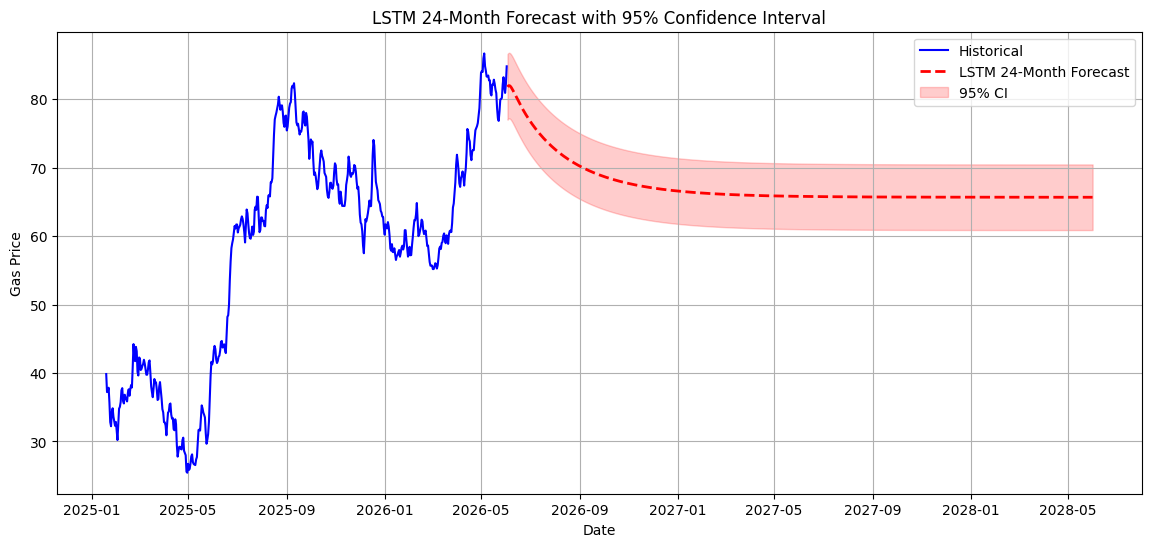

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["daily price"], label="Historical", color="blue")

plt.plot(
    future_index,
    future_forecast,
    "--",
    color="red",
    linewidth=2,
    label="LSTM 24-Month Forecast"
)

plt.fill_between(
    future_index,
    future_lower,
    future_upper,
    color="red",
    alpha=0.2,
    label="95% CI"
)

plt.title("LSTM 24-Month Forecast with 95% Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
#hp tuning

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

param_grid = {
    "units": [32, 64, 96],
    "dropout": [0.1, 0.2, 0.3],
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.0005]
}


In [20]:
def build_lstm(units, dropout, lr):
    model = Sequential([
        LSTM(units, return_sequences=False, input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse"
    )
    return model


In [21]:
results = []
best_rmse = float("inf")
best_params = None

for units in param_grid["units"]:
    for dropout in param_grid["dropout"]:
        for batch in param_grid["batch_size"]:
            for lr in param_grid["learning_rate"]:

                model = build_lstm(units, dropout, lr)

                early_stop = EarlyStopping(
                    monitor="val_loss",
                    patience=10,
                    restore_best_weights=True
                )

                history = model.fit(
                    X_train, y_train,
                    epochs=100,
                    batch_size=batch,
                    validation_split=0.2,
                    shuffle=False,
                    callbacks=[early_stop],
                    verbose=0
                )

                # validation predictions
                val_pred_scaled = model.predict(X_train[int(len(X_train)*0.8):], verbose=0)
                val_actual = y_train[int(len(y_train)*0.8):]

                val_pred = scaler.inverse_transform(val_pred_scaled)
                val_actual = scaler.inverse_transform(val_actual)

                rmse = np.sqrt(mean_squared_error(val_actual, val_pred))

                results.append({
                    "units": units,
                    "dropout": dropout,
                    "batch": batch,
                    "lr": lr,
                    "val_RMSE": rmse
                })

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_params = (units, dropout, batch, lr)

print("Best params:", best_params)
print("Best validation RMSE:", best_rmse)


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\sagal\OneDrive\Desk

Best params: (64, 0.1, 16, 0.001)
Best validation RMSE: 1.8886544919699821


In [22]:
results_df = pd.DataFrame(results).sort_values("val_RMSE").reset_index(drop=True)
results_df


,units,dropout,batch,lr,val_RMSE
0,64,0.1,16,0.0010,1.888654
1,64,0.3,16,0.0010,1.892583
2,96,0.3,32,0.0010,1.970556
3,96,0.1,32,0.0010,1.973305
4,96,0.2,16,0.0005,2.003755
5,96,0.2,16,0.0010,2.014457
6,96,0.1,16,0.0005,2.052817
7,96,0.2,32,0.0010,2.085711
8,64,0.2,32,0.0010,2.096553
9,64,0.2,16,0.0010,2.117276


In [23]:
results_df.head()
best_params


(64, 0.1, 16, 0.001)

In [33]:
best_units = 64
best_dropout = 0.1
best_batch = 16
best_lr = 0.001

final_model = Sequential([
    LSTM(best_units, return_sequences=False, input_shape=(lookback, 1)),
    Dropout(best_dropout),
    Dense(1)
])

final_model.compile(
    optimizer=Adam(learning_rate=best_lr),
    loss="mse"
)

final_model.summary()


c:\Users\sagal\OneDrive\Desktop\gas-price-forecasting\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = final_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=best_batch,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0544 - val_loss: 0.0151
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0287 - val_loss: 0.0041
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112 - val_loss: 0.0028
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0139 - val_loss: 0.0058
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - val_loss: 0.0028
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0092 - val_loss: 0.0038
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070 - val_loss: 0.0030
Epoch 8/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0064 - val_loss: 0.0030
Epoch 9/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - val_loss: 0.0028
Epoch 10/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0063 - val_loss: 0.0032
Epoch 11/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - val_loss: 0.0027
Epoch 12/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

In [35]:
y_pred_scaled = final_model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)

y_test_actual = scaler.inverse_transform(y_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [36]:
residuals = y_test_actual.flatten() - y_pred.flatten()
residual_std = np.std(residuals)

lower_ci = y_pred.flatten() - 1.96 * residual_std
upper_ci = y_pred.flatten() + 1.96 * residual_std


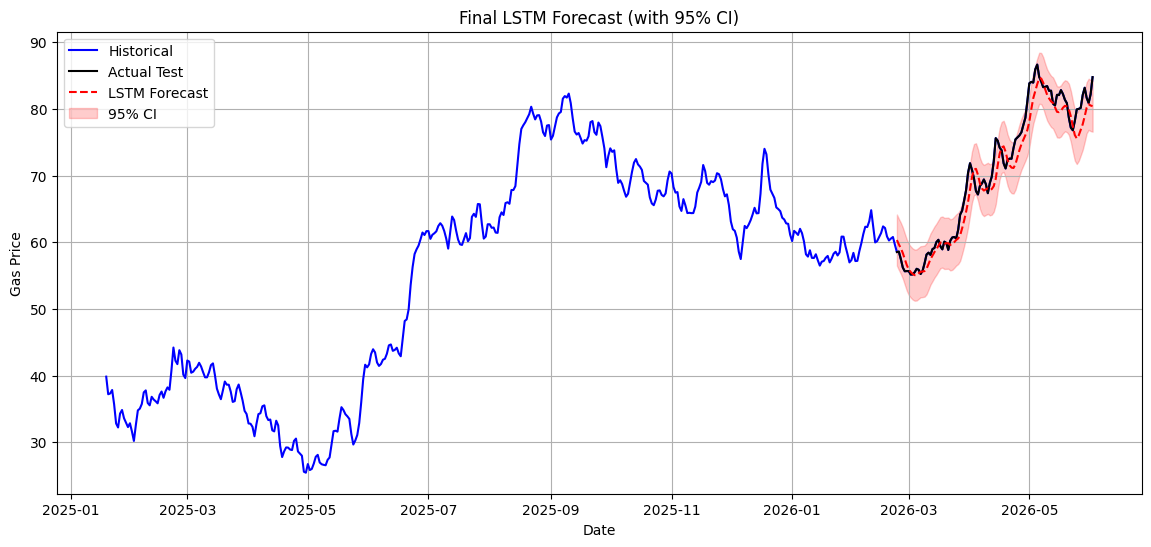

In [42]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["daily price"], label="Historical", color="blue")
plt.plot(test.index, y_test_actual, label="Actual Test", color="black")
plt.plot(test.index, y_pred, label="LSTM Forecast", color="red", linestyle="--")

plt.fill_between(
    test.index,
    lower_ci,
    upper_ci,
    color="red",
    alpha=0.2,
    label="95% CI"
)

plt.title("Final LSTM Forecast (with 95% CI)")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


In [38]:
future_steps = 730

full_scaled = scaler.transform(df.values.reshape(-1, 1))
last_window = full_scaled[-lookback:].reshape(1, lookback, 1)

future_scaled = []

for _ in range(future_steps):
    next_pred = final_model.predict(last_window, verbose=0)[0, 0]
    future_scaled.append(next_pred)

    last_window = np.append(
        last_window[:,1:,:],
        [[[next_pred]]],
        axis=1
    )

future_forecast = scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
)


In [39]:
ci = 1.96 * np.sqrt(mean_squared_error(y_test_actual, y_pred))

future_lower = future_forecast.flatten() - ci
future_upper = future_forecast.flatten() + ci

future_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="D"
)


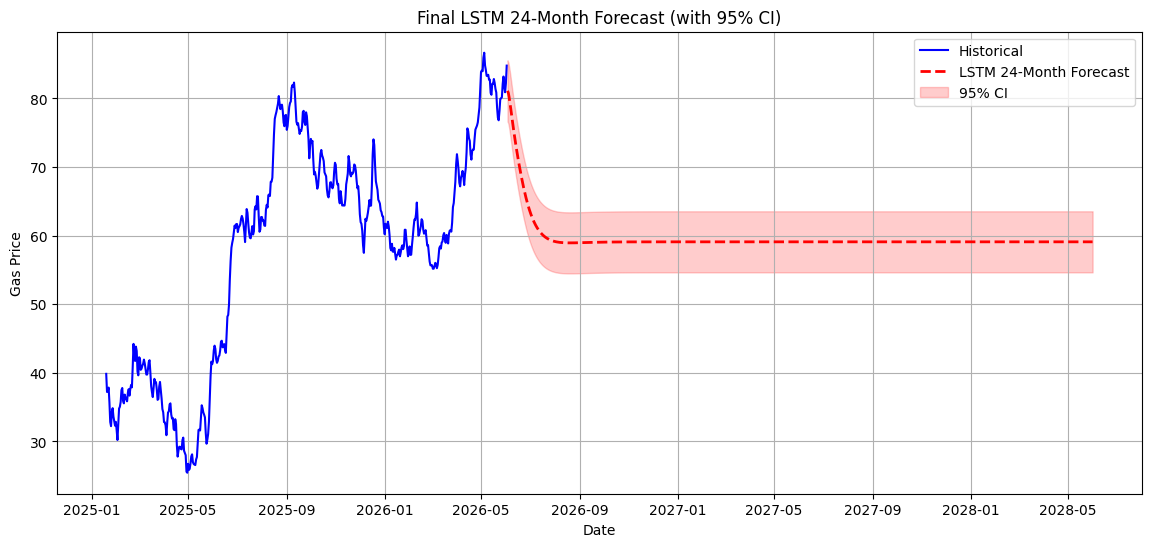

In [40]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["daily price"], label="Historical", color="blue")
plt.plot(future_index, future_forecast, "--", color="red", linewidth=2, label="LSTM 24-Month Forecast")

plt.fill_between(
    future_index,
    future_lower,
    future_upper,
    color="red",
    alpha=0.2,
    label="95% CI"
)

plt.title("Final LSTM 24-Month Forecast (with 95% CI)")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.grid(True)
plt.show()


In [41]:

y_true = y_test_actual.flatten()
y_predicted = y_pred.flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_true, y_predicted))
lstm_mae = mean_absolute_error(y_true, y_predicted)
lstm_mape = np.mean(np.abs((y_true - y_predicted) / y_true)) * 100

print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM MAE: {lstm_mae:.4f}")
print(f"LSTM MAPE: {lstm_mape:.2f}%")


LSTM RMSE: 2.2712
LSTM MAE: 1.7963
LSTM MAPE: 2.47%


In [43]:
import json

lstm_metrics = {
    "model": "LSTM (tuned)",
    "rmse": float(lstm_rmse),
    "mae": float(lstm_mae),
    "mape": float(lstm_mape)
}

with open("../model_outputs/lstm_metrics.json", "w") as f:
    json.dump(lstm_metrics, f, indent=4)
